# 🚜 Farm Machinery Predictive Maintenance: ML for AgTech

**Author:** Dean Wang | Lead Data & AI Engineer

**Government:** DAFF, AgriFutures Australia, GRDC, CSIRO Agriculture & Food

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2200, 13)


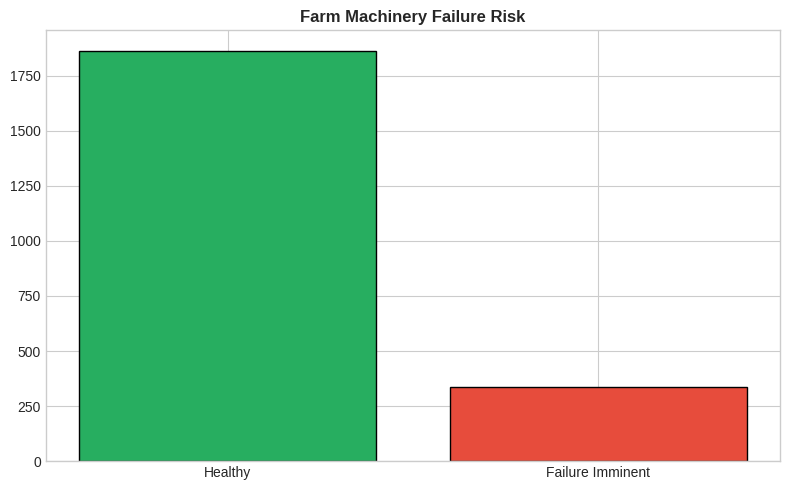

AU: Breakdown during harvest can cost $10,000s/day. Precision AgTech adoption accelerating.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2200,n_features=12,n_informative=9,n_classes=2,weights=[0.85,0.15],random_state=136)
names=['engine_hours','oil_temperature','hydraulic_pressure','vibration_rms','fuel_consumption_rate','coolant_temp','load_factor','age_years','last_service_hours','error_code_count','ambient_dust','component_wear_index']
df=pd.DataFrame(X_arr,columns=names);df['failure_imminent']=y;tc='failure_imminent'
print(f"Generated: {df.shape}");labels=['Healthy','Failure Imminent'];colors=['#27ae60','#e74c3c']
fig,ax=plt.subplots(figsize=(8,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(2),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(2));ax.set_xticklabels(labels)
ax.set_title('Farm Machinery Failure Risk',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: Breakdown during harvest can cost $10,000s/day. Precision AgTech adoption accelerating.")

LogReg: Acc=0.8836 F1=0.5361 AUC=0.8906
RF: Acc=0.9332 F1=0.7511 AUC=0.9600
XGB: Acc=0.9468 F1=0.8125 AUC=0.9660
LGBM: Acc=0.9482 F1=0.8161 AUC=0.9685
Best: LGBM


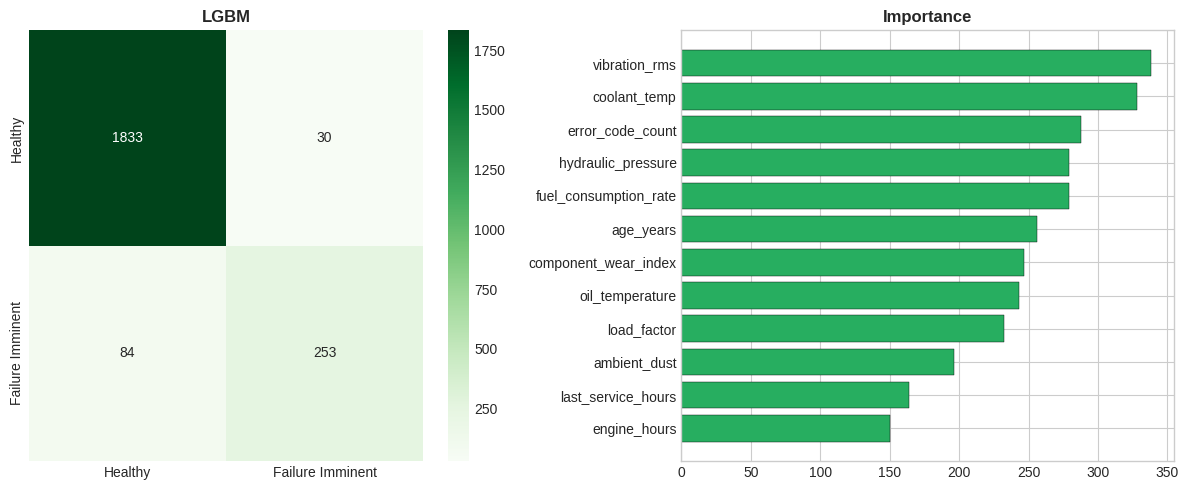

                  precision    recall  f1-score   support

         Healthy       0.96      0.98      0.97      1863
Failure Imminent       0.89      0.75      0.82       337

        accuracy                           0.95      2200
       macro avg       0.93      0.87      0.89      2200
    weighted avg       0.95      0.95      0.95      2200

DEPLOYMENT: LGBM AUC=0.9685 | Telematics/CAN bus -> scheduled maintenance before harvest


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fu=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp));fu.append(roc_auc_score(y2[vi],yb))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")
best=max(results,key=lambda k:results[k]['auc']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',xticklabels=labels,yticklabels=labels,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#27ae60',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=labels))
br=results[best];print(f"DEPLOYMENT: {best} AUC={br['auc']:.4f} | Telematics/CAN bus -> scheduled maintenance before harvest")